# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [1]:
import pandas as pd

df = pd.read_csv('./data.csv')
df.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_universitypast_failures
0,16,4,4,1,2,5,4,4.0,1.0,2.0,5,1,1,0,1,1,10
1,17,4,4,1,1,5,3,4.0,1.0,2.0,5,0,1,0,1,1,10
2,16,1,1,2,1,4,5,5.0,2.0,4.0,5,1,0,1,1,1,10
3,18,1,2,2,1,3,4,4.0,2.0,4.0,4,1,1,0,1,0,-10
4,17,2,1,2,2,4,2,5.0,1.0,2.0,5,0,0,0,1,1,10


In [2]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_universitypast_failures
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,648.000000,639.000000,643.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,50.164869,2.514638,2.306626,1.747304,1.930663,3.930663,3.180277,3.186728,1.497653,2.286159,3.536210,0.409861,0.696456,0.295840,0.876733,0.802773,7.935285
std,254.768848,1.134552,1.099931,2.716138,0.829510,0.955717,1.051093,1.175751,0.924879,1.285764,1.446259,0.492187,0.460143,0.456771,0.328996,0.398212,6.475653
min,15.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,1.000000,10.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000
max,1991.000000,4.000000,4.000000,50.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.000000


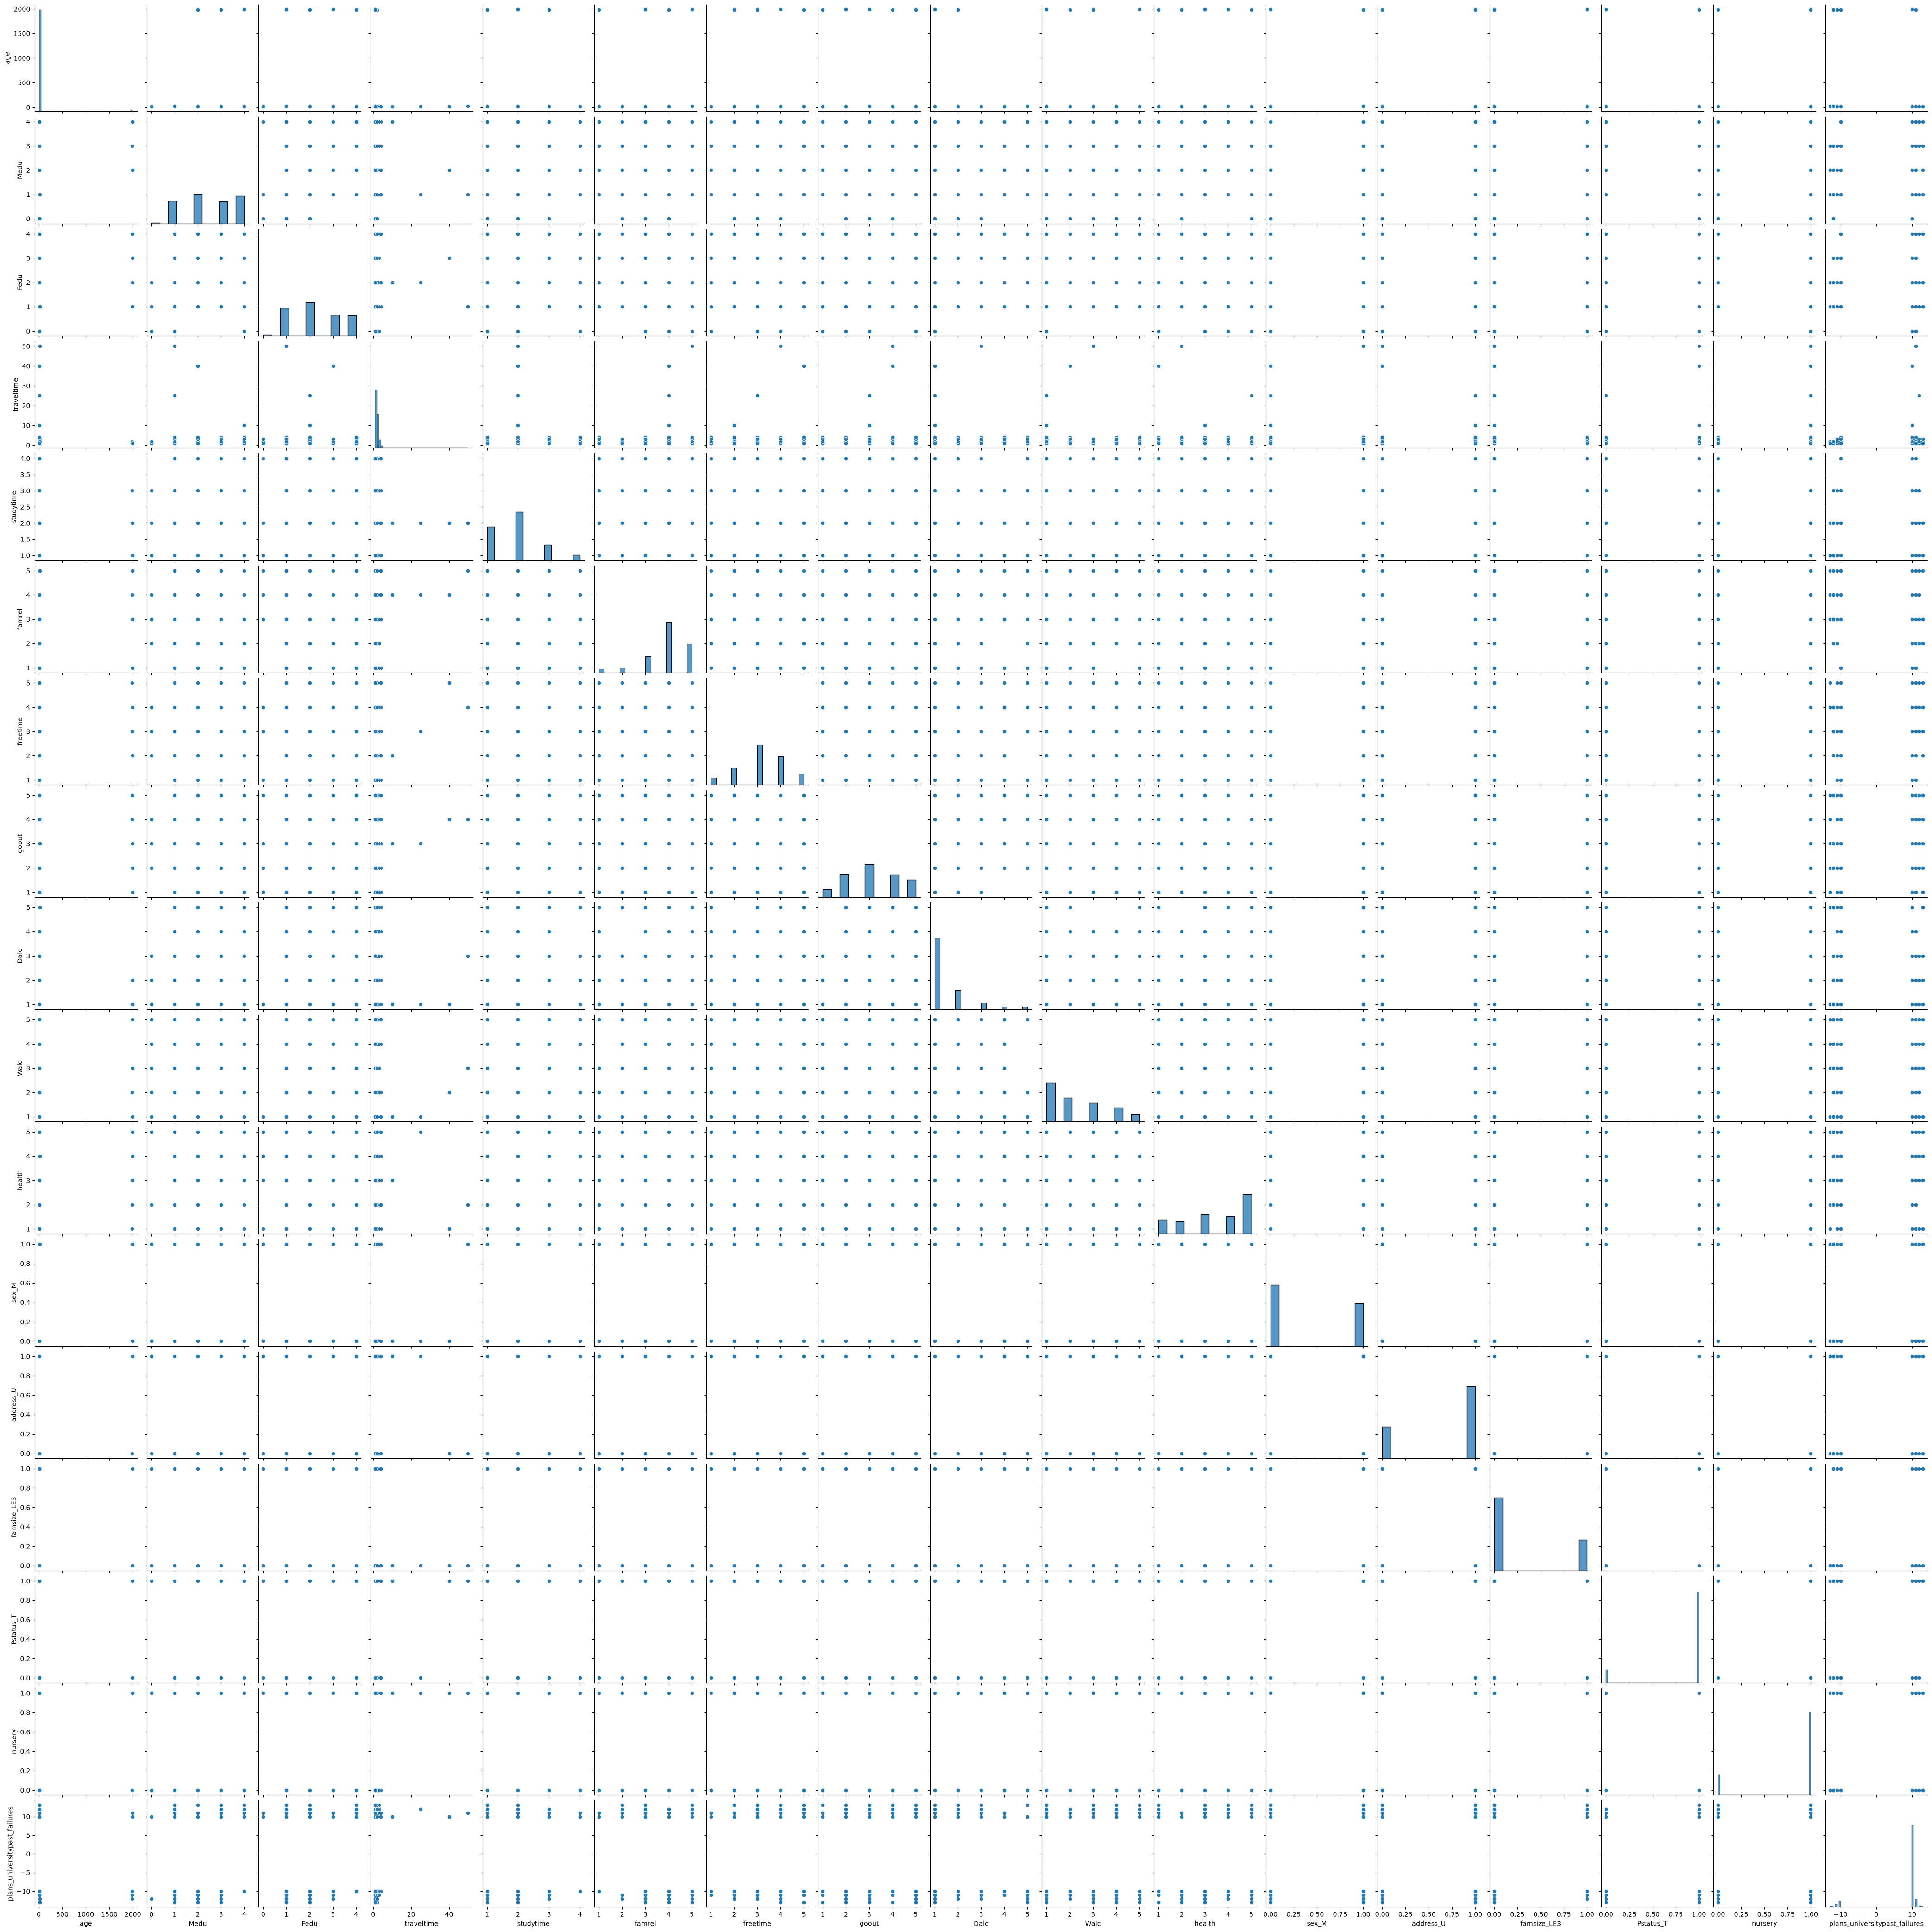

In [3]:
import seaborn as sns

sns.pairplot(df)

In [4]:
# clip age
# plans_university + past_failures
# travel_time anomaly

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('./data.csv')

df['age'] = df['age'].apply(lambda x: 2006 - x if x > 1900 else x)

def fix_traveltime(x):
    if x > 4:
        if x < 15: return 1
        elif x < 30: return 2
        elif x < 60: return 3
        else: return 4
    return x

df['traveltime'] = df['traveltime'].apply(fix_traveltime)

df['plans_university'] = np.where(df['plans_universitypast_failures'] > 0, 1, -1)
df['past_failures'] = abs(df['plans_universitypast_failures']) % 10
df = df.drop(columns=['plans_universitypast_failures'])

df.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
0,16,4,4,1,2,5,4,4.0,1.0,2.0,5,1,1,0,1,1,1,0
1,17,4,4,1,1,5,3,4.0,1.0,2.0,5,0,1,0,1,1,1,0
2,16,1,1,2,1,4,5,5.0,2.0,4.0,5,1,0,1,1,1,1,0
3,18,1,2,2,1,3,4,4.0,2.0,4.0,4,1,1,0,1,0,-1,0
4,17,2,1,2,2,4,2,5.0,1.0,2.0,5,0,0,0,1,1,1,0


In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,648.000000,639.000000,643.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,3.930663,3.180277,3.186728,1.497653,2.286159,3.536210,0.409861,0.696456,0.295840,0.876733,0.802773,0.787365,0.221880
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.955717,1.051093,1.175751,0.924879,1.285764,1.446259,0.492187,0.460143,0.456771,0.328996,0.398212,0.616962,0.593235
min,15.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [7]:
df = df.fillna(df.mean())

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               649 non-null    int64  
 1   Medu              649 non-null    int64  
 2   Fedu              649 non-null    int64  
 3   traveltime        649 non-null    int64  
 4   studytime         649 non-null    int64  
 5   famrel            649 non-null    int64  
 6   freetime          649 non-null    int64  
 7   goout             649 non-null    float64
 8   Dalc              649 non-null    float64
 9   Walc              649 non-null    float64
 10  health            649 non-null    int64  
 11  sex_M             649 non-null    int64  
 12  address_U         649 non-null    int64  
 13  famsize_LE3       649 non-null    int64  
 14  Pstatus_T         649 non-null    int64  
 15  nursery           649 non-null    int64  
 16  plans_university  649 non-null    int64  
 17  past_fai

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

df_scaled.head()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
0,-0.611422,1.310216,1.540715,-0.760032,0.083653,1.119748,0.780478,0.692772,-0.542692,-0.223769,1.012903,1.199937,0.660182,-0.648175,0.374963,0.495663,0.344914,-0.374305
1,0.210137,1.310216,1.540715,-0.760032,-1.122808,1.119748,-0.171647,0.692772,-0.542692,-0.223769,1.012903,-0.833377,0.660182,-0.648175,0.374963,0.495663,0.344914,-0.374305
2,-0.611422,-1.336039,-1.188832,0.576718,-1.122808,0.072606,1.732603,1.544607,0.547811,1.340184,1.012903,1.199937,-1.514733,1.542792,0.374963,0.495663,0.344914,-0.374305
3,1.031695,-1.336039,-0.278983,0.576718,-1.122808,-0.974536,0.780478,0.692772,0.547811,1.340184,0.320930,1.199937,0.660182,-0.648175,0.374963,-2.017502,-2.899275,-0.374305
4,0.210137,-0.453954,-1.188832,0.576718,0.083653,0.072606,-1.123771,1.544607,-0.542692,-0.223769,1.012903,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.344914,-0.374305


In [9]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,3.930663,3.180277,3.186728,1.497653,2.286159,3.536210,0.409861,0.696456,0.295840,0.876733,0.802773,0.787365,0.221880
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.955717,1.051093,1.174843,0.917715,1.279797,1.446259,0.492187,0.460143,0.456771,0.328996,0.398212,0.616962,0.593235
min,15.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

scores = pd.read_csv('./scores.csv', header=None).values.ravel()

lr = LinearRegression()
cv_scores = cross_val_score(lr, df_scaled, scores, cv=4, scoring='neg_mean_squared_error')

print("MSE по фолдам (исходные данные):", -cv_scores)
print("Средний MSE:", -cv_scores.mean())

MSE по фолдам (исходные данные): [165.53787224 242.93379682 237.9481047  233.4677314 ]
Средний MSE: 219.97187628852868


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [12]:
attendance = pd.read_csv('./attendance.csv', sep=';')
attended_classes = (attendance == '+').sum(axis=1).values

with open('./school_support.txt', 'r') as f:
    support_indices = [int(line.strip()) for line in f.readlines()]

school_support = np.zeros(len(df_scaled))
school_support[support_indices] = 1

df_full = df_scaled.copy()
df_full['attendance'] = scaler.fit_transform(attended_classes.reshape(-1, 1))
df_full['school_support'] = school_support

cv_scores_full = cross_val_score(lr, df_full, scores, cv=4, scoring='neg_mean_squared_error')
print("MSE по фолдам (с добавленными признаками):", -cv_scores_full)
print("Средний MSE:", -cv_scores_full.mean())

MSE по фолдам (с добавленными признаками): [159.48080432 237.70952975 246.68717342 233.40122005]
Средний MSE: 219.31968188660971


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

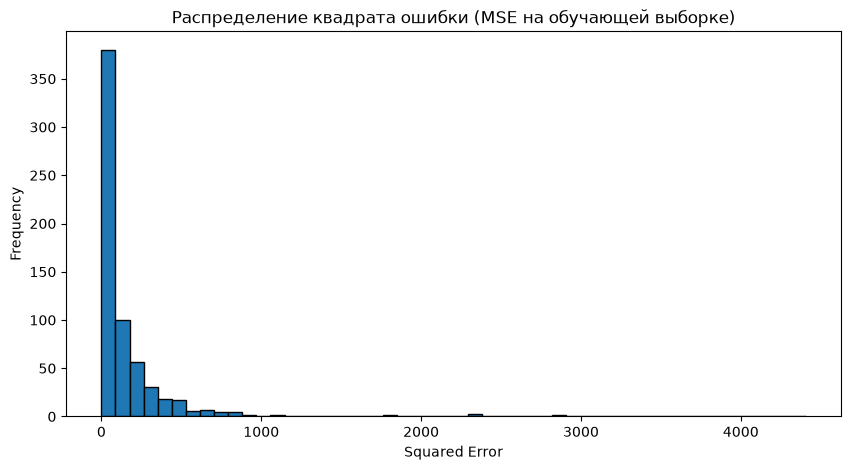

Индексы объектов с наибольшей ошибкой: [423 404 462 257 303 319 385 615 585 354]
Их исходные оценки (scores): [0.   0.55 0.   0.55 0.   0.   0.   0.   0.7  0.  ]


In [13]:
import matplotlib.pyplot as plt
from sklearn import linear_model

regression = linear_model.LinearRegression().fit(df_full, scores)
prediction = regression.predict(df_full) 
error = (prediction - scores)**2 

plt.figure(figsize=(10, 5))
plt.hist(error, bins=50, edgecolor='black')
plt.title("Распределение квадрата ошибки (MSE на обучающей выборке)")
plt.xlabel("Squared Error")
plt.ylabel("Frequency")
plt.show()

bad_indices = np.argsort(error)[-10:]
print("Индексы объектов с наибольшей ошибкой:", bad_indices)
print("Их исходные оценки (scores):", scores[bad_indices])

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

In [15]:
scores_fixed = scores.copy()

scores_fixed = np.where((scores_fixed > 0) & (scores_fixed <= 1.0), scores_fixed * 100, scores_fixed)
scores_fixed = np.where((scores_fixed > 1.0) & (scores_fixed <= 10.0), scores_fixed * 10, scores_fixed)
scores_fixed = np.where(scores_fixed > 100, scores_fixed / 10, scores_fixed)

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [16]:
cv_scores_final = cross_val_score(lr, df_full, scores_fixed, cv=4, scoring='neg_mean_squared_error')
print("Финальный MSE по фолдам:", -cv_scores_final)
print("Финальный средний MSE:", -cv_scores_final.mean())

Финальный MSE по фолдам: [154.1850264  196.80230168 214.92667662 208.36201308]
Финальный средний MSE: 193.56900444494158


1. Базовая модель на нормализованных и очищенных данных дала MSE ~219.97
2. Добавление новых признаков (**attendance** и **school_support**) помогло уменьшить MSE до ~219.32
3. Анализ ошибок модели помог выявить _scaling error_ в predicted data. Исправление ошибки в **train** помогло уменьшить (значительно) MSE до ~193.57